## Principal Component Analysis

Principal Component Analysis (PCA) is a tool used to compress the dimensionality of a dataset. It is particularly useful for building compact emulators. The idea is to find the directions (eigenvectors) along which the data varies most, discard all but the top $n$, and train an emulator to predict coefficients on those axes rather than the full output vector.

Here we apply PCA to the 2500 `zeus21` 21-cm power spectra used in the GP and neural network emulator notebooks. Each power spectrum is evaluated at 54 $k$-modes, so the raw output dimension is 54. We will show that just a handful of PCA components captures nearly all of the variance across the training set.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

### Training data

We load the 2500 `zeus21` power spectrum realisations. Each is saved as an `.npz` file containing the $k$-modes, the power spectrum $\Delta^2(k)$, and the astrophysical/cosmological parameters used to generate it.

In [ ]:
simulations = [np.load(f"../simulations/sample_{i:06d}.npz",
                       allow_pickle=True) for i in range(2500)]

k      = simulations[0]["k"]
powers = np.array([sim["power"] for sim in simulations])

# Plot a handful of examples
fig, ax = plt.subplots(figsize=(5, 3))
for i in range(0, 2500, 500):
    ax.loglog(k, powers[i], c='k', alpha=0.6)
ax.set_xlabel(r'$k$  [Mpc$^{-1}$]')
ax.set_ylabel(r'$\Delta^2(k)$  [mK$^2$]')
ax.set_title('Sample power spectra')
plt.tight_layout()
plt.savefig('power-spectra.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Data shape: {powers.shape}  ({powers.shape[0]} simulations, {powers.shape[1]} k-modes)')

### Normalisation

For many datasets it is necessary to normalise the data before applying PCA — for example by subtracting the mean spectrum or dividing by the standard deviation — to prevent the decomposition being dominated by the overall dynamic range rather than the shape variations. For the 21-cm power spectra here the raw values work fine, so we pass them directly to PCA.

In [ ]:
norm_powers = powers  # no normalisation needed here

### PCA decomposition

We compute the covariance matrix of the normalised power spectra and find its eigenvectors and eigenvalues. Each eigenvector represents a direction of variance in the 54-dimensional $k$-space; the corresponding eigenvalue tells us how much of the total variance is explained by that direction.

In [8]:
cov = np.cov(norm_powers, rowvar=False)
eig_vals, eig_vecs = np.linalg.eig(cov)

### Sort the eigenvectors

We sort eigenvalues from largest to smallest and compute the cumulative explained variance. This tells us how many components we need to retain to capture a given fraction of the total variance in the training set.

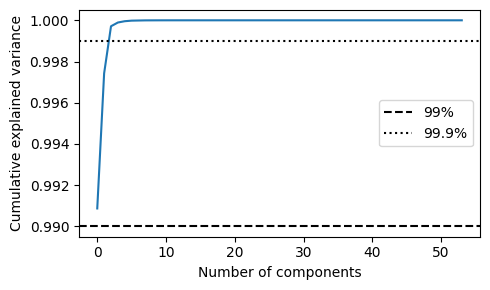

99.0% variance explained by 1 components
99.9% variance explained by 3 components
100.0% variance explained by 5 components


In [9]:
args = np.argsort(eig_vals)[::-1]
eig_vals = np.real(eig_vals[args])
eig_vecs = eig_vecs[:, args]

explained_variance            = eig_vals / np.sum(eig_vals)
cumulative_explained_variance = np.cumsum(explained_variance)

plt.figure(figsize=(5, 3))
plt.plot(cumulative_explained_variance)
plt.axhline(0.99, ls='--', c='k', label='99%')
plt.axhline(0.999, ls=':', c='k', label='99.9%')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.tight_layout()
plt.savefig('cumulative-explained-variance.png', dpi=300, bbox_inches='tight')
plt.show()

for threshold in [0.99, 0.999, 0.9999]:
    n = np.searchsorted(cumulative_explained_variance, threshold) + 1
    print(f'{100*threshold:.1f}% variance explained by {n} components')

Only a small number of components is needed to explain nearly all the variance — a dramatic compression from 54 $k$-modes down to ~5–10 numbers. An emulator (GP or neural network) only needs to predict these few coefficients; the full power spectrum is then reconstructed by multiplying by the stored eigenvectors.

Below we project the training data onto the top components, reconstruct the first test spectrum, and inspect the residual.

In [ ]:
ncomponents = 6

# Project all spectra onto the top components
pca_coeffs = np.dot(norm_powers, eig_vecs[:, :ncomponents])

# Reconstruct the first spectrum
idx = 0
reconstructed = np.dot(pca_coeffs[idx], eig_vecs[:, :ncomponents].T)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for j in range(ncomponents):
    axes[0].semilogx(k, pca_coeffs[idx, j] * eig_vecs[:, j], label=f'PC {j+1}')
axes[0].set_xlabel(r'$k$  [Mpc$^{-1}$]')
axes[0].set_ylabel('Contribution')
axes[0].set_title('PCA components')
axes[0].legend(fontsize=7)

axes[1].loglog(k, powers[idx],   label='Original')
axes[1].loglog(k, reconstructed, label=f'PCA ({ncomponents} components)', ls='--')
axes[1].set_xlabel(r'$k$  [Mpc$^{-1}$]')
axes[1].set_ylabel(r'$\Delta^2(k)$  [mK$^2$]')
axes[1].set_title('Reconstructed spectrum')
axes[1].legend()

frac_residual = 100 * np.abs(powers[idx] - reconstructed) / np.abs(powers[idx])
axes[2].semilogx(k, frac_residual)
axes[2].set_xlabel(r'$k$  [Mpc$^{-1}$]')
axes[2].set_ylabel('Fractional residual (%)')
axes[2].set_title('Residual')

plt.tight_layout()
plt.savefig('reconstructed-spectrum.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Mean fractional residual: {frac_residual.mean():.3f} %')